In [ ]:
!pip install kneed

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Kneedle algorithm for elbow point detection
from kneed import KneeLocator

In [11]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y_true = iris.target

In [12]:
print("First 5 rows of the dataset:")
print(X.head())

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [13]:
print("\nDataset Description:")
print(X.describe())


Dataset Description:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [5]:
print("\nCheck for Missing Values:")
print(X.isnull().sum())


Check for Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [6]:
X.duplicated().sum()

np.int64(1)

In [8]:
X = X.drop_duplicates()

In [9]:
X.shape

(149, 4)

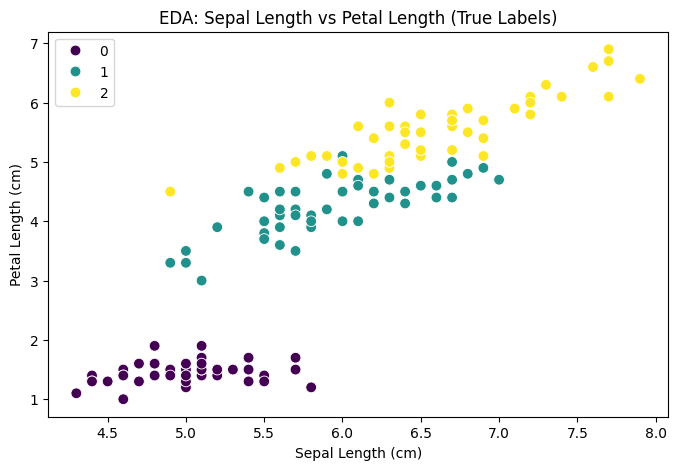

In [14]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X['sepal length (cm)'], y=X['petal length (cm)'], hue=y_true, palette='viridis', s=60)
plt.title('EDA: Sepal Length vs Petal Length (True Labels)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.show()

In [15]:
X_train, X_test, y_train_true, y_test_true = train_test_split(
    X, y_true, test_size=0.2, random_state=42, stratify=y_true
)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Test set size: 30 samples


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled

array([[-1.72156775, -0.33210111, -1.34572231, -1.32327558],
       [-1.12449223, -1.22765467,  0.41450518,  0.6517626 ],
       [ 1.14439475, -0.5559895 ,  0.58484978,  0.25675496],
       [-1.12449223,  0.11567567, -1.28894078, -1.45494479],
       [-0.40800161, -1.22765467,  0.13059752,  0.12508575],
       [ 0.54731923, -1.22765467,  0.69841284,  0.91510102],
       [-0.2885865 , -0.77987789,  0.24416059,  0.12508575],
       [ 0.54731923, -0.5559895 ,  0.75519438,  0.38842418],
       [ 2.21913069, -0.10821272,  1.3230097 ,  1.44177787],
       [ 2.21913069,  1.6828944 ,  1.66369889,  1.31010866],
       [ 2.09971558, -0.10821272,  1.60691736,  1.17843945],
       [ 0.18907392, -0.33210111,  0.41450518,  0.38842418],
       [-1.00507713, -2.34709662, -0.15331014, -0.26992188],
       [-0.04975629, -0.77987789,  0.18737906, -0.26992188],
       [-0.04975629, -1.00376628,  0.13059752, -0.00658346],
       [-1.36332244,  0.33956406, -1.23215924, -1.32327558],
       [-0.88566202,  1.

In [18]:
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
print("\nWCSS values for k=1 to 10 (Train Set):")



WCSS values for k=1 to 10 (Train Set):


In [19]:
wcss

[480.0,
 181.22793853170515,
 110.28230477122315,
 89.26897746822772,
 76.28909508190722,
 65.19930362260608,
 57.17592598186454,
 50.12602189238543,
 42.89812351563057,
 38.84769476643305]

In [20]:
for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.4f}")

k=1: WCSS=480.0000
k=2: WCSS=181.2279
k=3: WCSS=110.2823
k=4: WCSS=89.2690
k=5: WCSS=76.2891
k=6: WCSS=65.1993
k=7: WCSS=57.1759
k=8: WCSS=50.1260
k=9: WCSS=42.8981
k=10: WCSS=38.8477


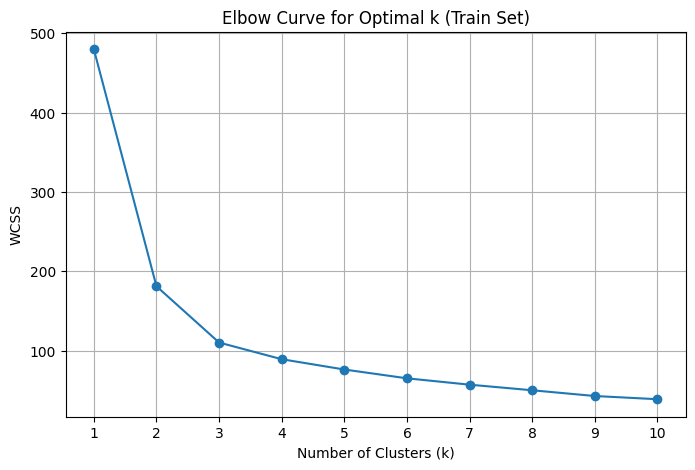

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Curve for Optimal k (Train Set)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [22]:
knee = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow
print(f"\nOptimal number of clusters (Kneedle): {optimal_k}")


Optimal number of clusters (Kneedle): 3


In [23]:
silhouette_scores = []
for k in k_range[1:]:  # Start from k=2, as silhouette score is undefined for k=1
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_scores.append(score)
print("\nSilhouette scores for k=2 to 10 (Train Set):")


Silhouette scores for k=2 to 10 (Train Set):


In [24]:
for k, s in zip(k_range[1:], silhouette_scores):
    print(f"k={k}: Silhouette Score={s:.4f}")

k=2: Silhouette Score=0.5759
k=3: Silhouette Score=0.4845
k=4: Silhouette Score=0.4166
k=5: Silhouette Score=0.3284
k=6: Silhouette Score=0.3299
k=7: Silhouette Score=0.3381
k=8: Silhouette Score=0.3323
k=9: Silhouette Score=0.3509
k=10: Silhouette Score=0.3522


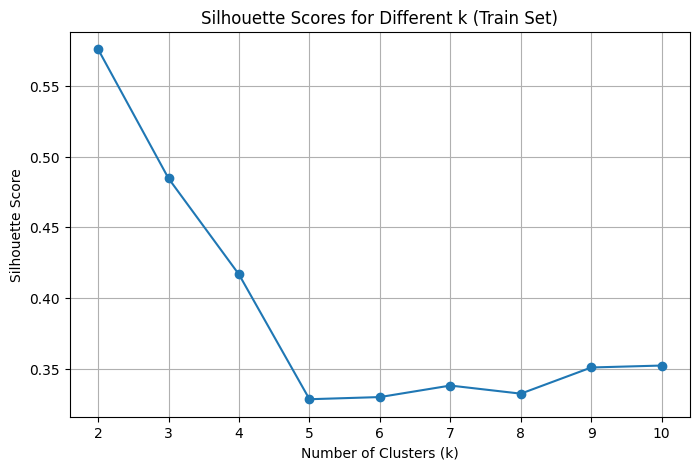

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(k_range[1:], silhouette_scores, marker='o')
plt.title('Silhouette Scores for Different k (Train Set)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range[1:])
plt.grid(True)
plt.show()

In [26]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y_train_clusters = kmeans.fit_predict(X_train_scaled)
y_test_clusters = kmeans.predict(X_test_scaled)

In [27]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

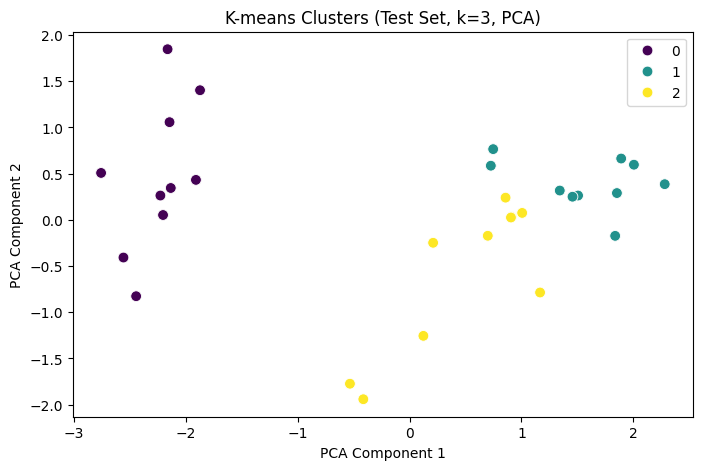

In [28]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test_clusters, palette='viridis', s=60)
plt.title(f'K-means Clusters (Test Set, k={optimal_k}, PCA)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()